In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

## Cambiar el formato de los números
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_colwidth', None) # configurar vista de las columnas categóricas
pd.set_option('display.max_columns', None) # para no limitar la visualización de la cantidad de columnas

In [2]:
# se debe agregar la ruta apropiada
ruta1 = '/content/data_dncp.csv'
#ruta2 = '/content/data_dncp2.csv'

data = pd.read_csv(ruta1, on_bad_lines='skip', engine='python')
#data2 = pd.read_csv(ruta2, on_bad_lines='skip', engine='python')

In [3]:
data.shape

(50000, 27)

In [4]:
print(f"Shape of data before dropping duplicates: {data.shape}")

duplicates_count = data['Open Contracting ID'].duplicated().sum()

if duplicates_count > 0:
    print(f"Found {duplicates_count} duplicate 'Open Contracting ID' entries. Removing duplicates...")
    data.drop_duplicates(subset=['Open Contracting ID'], inplace=True)
    print(f"Shape of data after dropping duplicates: {data.shape}")
else:
    print("No duplicate 'Open Contracting ID' entries found.")

Shape of data before dropping duplicates: (50000, 27)
Found 9001 duplicate 'Open Contracting ID' entries. Removing duplicates...
Shape of data after dropping duplicates: (40999, 27)


In [5]:
#solo licitaciones en guaranies
data = data[(data['compiledRelease/contracts/0/value/currency'] == 'PYG')]

In [6]:
# Convertir las variables de fechas en tipo datetime
data['compiledRelease/contracts/0/period/endDate'] = pd.to_datetime(data['compiledRelease/contracts/0/period/endDate'])
data['compiledRelease/contracts/0/period/startDate'] = pd.to_datetime(data['compiledRelease/contracts/0/period/startDate'])
data['compiledRelease/contracts/0/dateSigned'] = pd.to_datetime(data['compiledRelease/contracts/0/dateSigned'])

# Calcular el periodo de los contratos en días, y luego llenar los campos nulos de la variable "compiledRelease/contracts/0/period/durationInDays" con
# estos valores
data['cant_dias_aux'] = (data['compiledRelease/contracts/0/period/endDate']-data['compiledRelease/contracts/0/period/startDate']).dt.days
data['compiledRelease/contracts/0/period/durationInDays'].fillna(data['cant_dias_aux'], inplace=True)

# Convertir la columna 'durationInDays' a numérica para asegurar que no haya strings.
data['compiledRelease/contracts/0/period/durationInDays'] = pd.to_numeric(data['compiledRelease/contracts/0/period/durationInDays'], errors='coerce')

# Eliminar los valores nulos de la columna "compiledRelease/contracts/0/period/durationInDays"
data = data[data['compiledRelease/contracts/0/period/durationInDays'].isnull()==False]
data = data[data['compiledRelease/tender/numberOfTenderers'].isnull()==False]


## Sustituir las categorías de la variable "'compiledRelease/tender/procurementMethodDetails" por unos alias.
categorias = data['compiledRelease/tender/procurementMethodDetails'].unique().tolist()
mapping = {'Concurso de Ofertas':'CO', 'Contratación Directa':'CD', 'Licitación Pública Nacional':'LPN'}
data['compiledRelease/tender/procurementMethodDetails'] = data['compiledRelease/tender/procurementMethodDetails'].replace(mapping)

## Generar variables asociadas a la duración de los contratos
lista_duracion_dias = data['compiledRelease/contracts/0/period/durationInDays'].tolist()
duracion_contrato_semanas = [round(x/7, 1) for x in lista_duracion_dias ]
duracion_contrato_meses = [round(x/30, 1) for x in lista_duracion_dias]

data['duracion_contrato_semanas'] = duracion_contrato_semanas
data['duracion_contrato_meses'] = duracion_contrato_meses

## Selecionar solamente las columnas relevantes para el análisis y el modelo.
columnas_para_el_modelo =  ['compiledRelease/contracts/0/id',
                            'compiledRelease/contracts/0/dateSigned',
                            'compiledRelease/tender/mainProcurementCategoryDetails',
                            'compiledRelease/tender/tenderPeriod/durationInDays',
                            'compiledRelease/tender/procurementMethodDetails',
                            'compiledRelease/tender/numberOfTenderers',
                            'compiledRelease/contracts/0/period/durationInDays',
                            'compiledRelease/contracts/0/value/amount',
                            'duracion_contrato_semanas',
                            'duracion_contrato_meses',
                            'compiledRelease/contracts/0/statusDetails'
                            ]
data = data[columnas_para_el_modelo]

## Asignar nombres más apropiados a las columnas.
data.rename(columns = {
    'compiledRelease/contracts/0/id':'id_contrato',
    'compiledRelease/contracts/0/dateSigned':'contract_date',
    'compiledRelease/tender/mainProcurementCategoryDetails':'categoria_llamado',
    'compiledRelease/tender/tenderPeriod/durationInDays': 'duracion_llamado_dias',
    'compiledRelease/tender/procurementMethodDetails': 'tipo_licitacion',
    'compiledRelease/tender/numberOfTenderers' : 'nro_oferentes',
    'compiledRelease/contracts/0/period/durationInDays': 'duracion_contrato_dias',
    'compiledRelease/contracts/0/value/amount': 'monto_contrato',
    'compiledRelease/contracts/0/statusDetails':'contract_status_details'}, inplace = True
            )

In [7]:
## Generar dataframes para cada tipo de Licitación
data_lpn = data[data['tipo_licitacion']=='LPN'].reset_index(drop=True)
data_co = data[data['tipo_licitacion']=='CO'].reset_index(drop=True)
data_cd = data[data['tipo_licitacion']=='CD'].reset_index(drop=True)


In [8]:
print('data_lpn.shape: ', data_lpn.shape)
print('data_co.shape: ', data_co.shape)
print('data_cd.shape: ', data_cd.shape)

data_lpn.shape:  (3791, 11)
data_co.shape:  (7920, 11)
data_cd.shape:  (23307, 11)


In [9]:
## EDA
data_lpn.describe()

,duracion_llamado_dias,nro_oferentes,duracion_contrato_dias,monto_contrato,duracion_contrato_semanas,duracion_contrato_meses
count,"3,791","3,791","3,791","3,791","3,791","3,791"
mean,36,6,379,"3,405,164,684",54,13
std,31,8,652,"12,721,134,224",93,22
min,19,1,0,0,0,0
25%,23,2,150,"407,691,000",21,5
50%,27,4,330,"1,013,857,000",47,11
75%,37,8,470,"2,211,369,978",67,16
max,577,110,"29,930","532,619,090,146","4,276",998


In [10]:
## EDA
data_cd.describe()

,duracion_llamado_dias,nro_oferentes,duracion_contrato_dias,monto_contrato,duracion_contrato_semanas,duracion_contrato_meses
count,"23,307","23,307","23,307","23,307","23,307","23,307"
mean,12,3,186,"59,441,791",27,6
std,8,2,558,"50,846,460",80,19
min,2,1,0,0,0,0
25%,7,1,45,"15,511,818",6,2
50%,9,2,120,"42,891,900",17,4
75%,14,3,242,"98,180,000",35,8
max,321,18,"73,365","454,520,000","10,481","2,446"


In [11]:
## EDA
data_co.describe()

,duracion_llamado_dias,nro_oferentes,duracion_contrato_dias,monto_contrato,duracion_contrato_semanas,duracion_contrato_meses
count,"7,920","7,920","7,920","7,920","7,920","7,920"
mean,16,3,285,"281,310,214",41,9
std,14,2,482,"204,436,621",69,16
min,6,1,0,0,0,0
25%,11,1,90,"126,112,500",13,3
50%,13,2,181,"240,471,148",26,6
75%,18,4,365,"400,000,000",52,12
max,728,24,"6,935","1,000,000,000",991,231


In [12]:
data_co['status_details'] = np.where(data_co['contract_status_details'] == 'Adjudicado', 1, 0)

In [13]:
## Classification KNN
#seleccionamos las variables
selected_data = ['nro_oferentes','duracion_llamado_dias','duracion_contrato_dias','monto_contrato','status_details']
knn_data = data_co[selected_data]

In [14]:
#data
X = knn_data.iloc[:, :-1].values
y = knn_data.iloc[:, -1].values

In [15]:
#split the data set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [16]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
# train the model and the set
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
#prediction
y_pred = classifier.predict(X_test)
#print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

In [19]:
#confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[   0    1]
 [   0 1979]]


0.9994949494949495

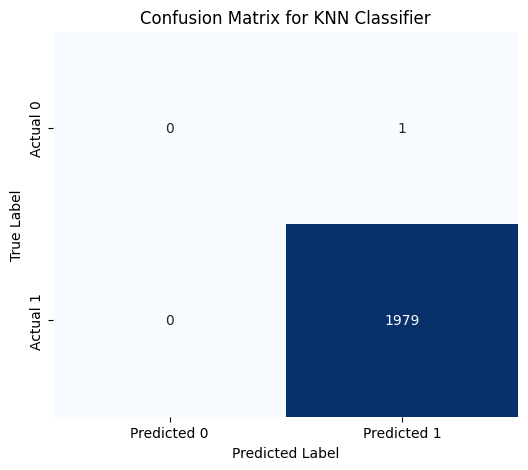

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [21]:
## multiple linnear regression
selected_data = ['nro_oferentes','monto_contrato','duracion_llamado_dias','duracion_contrato_dias','categoria_llamado']
mlr_data = data_co[selected_data][data_co['contract_date'].dt.year >= 2017]

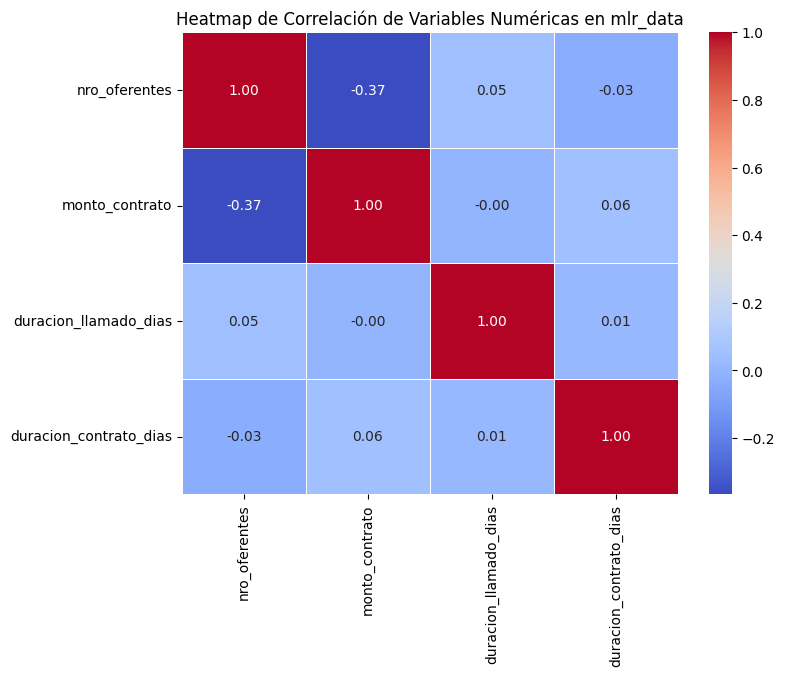

In [22]:
# Seleccionar solo las columnas numéricas de mlr_data
numerical_mlr_data = mlr_data.select_dtypes(include=['number'])

# Calcular la matriz de correlación
correlation_matrix_mlr = numerical_mlr_data.corr()

# Graficar el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_mlr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Variables Numéricas en mlr_data')
plt.show()

In [23]:
#making our data
X = mlr_data[['duracion_contrato_dias','nro_oferentes']].values
y = mlr_data['monto_contrato'].values

In [24]:
#split the data set into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [25]:
#train the model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [26]:
#prediction
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)

In [27]:
# Evaluate the model performance using R-squared and Mean Squared Error
from sklearn.metrics import r2_score, mean_squared_error

r_squared = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r_squared:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

R-squared: 0.12
Mean Squared Error: 39802001699614200.00


In [28]:
## Claustering KN
selected_data = ['nro_oferentes','duracion_llamado_dias']

# Ensure the columns are numeric before selecting them for X
data['nro_oferentes'] = pd.to_numeric(data['nro_oferentes'], errors='coerce')
data['duracion_llamado_dias'] = pd.to_numeric(data['duracion_llamado_dias'], errors='coerce')

# Filter data for year >= 2017 and then drop rows with NaN in the selected columns
X = data[data['contract_date'].dt.year >= 2017][selected_data].dropna()

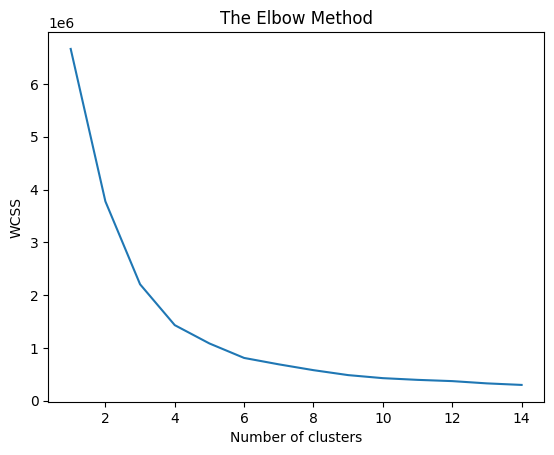

In [29]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 15), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
#prediction
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

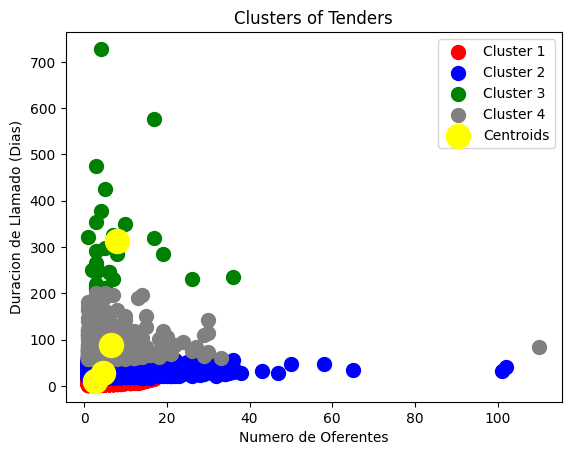

In [31]:
plt.scatter(X.values[y_kmeans == 0, 0], X.values[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X.values[y_kmeans == 1, 0], X.values[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X.values[y_kmeans == 2, 0], X.values[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X.values[y_kmeans == 3, 0], X.values[y_kmeans == 3, 1], s = 100, c = 'grey', label = 'Cluster 4')
#plt.scatter(X.values[y_kmeans == 4, 0], X.values[y_kmeans == 4, 1], s = 100, c = 'pink', label = 'Cluster 5')
#plt.scatter(X.values[y_kmeans == 5, 0], X.values[y_kmeans == 5, 1], s = 100, c = 'black', label = 'Cluster 6')
#plt.scatter(X.values[y_kmeans == 6, 0], X.values[y_kmeans == 6, 1], s = 100, c = 'brown', label = 'Cluster 7')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of Tenders')
plt.xlabel('Numero de Oferentes')
plt.ylabel('Duracion de Llamado (Dias)')
plt.legend()
plt.show()